<a href="https://colab.research.google.com/github/VenkataViswas/A_MTech-Sem2-Lab-Programs/blob/main/DL/image_denoising.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - loss: 0.2449 - val_loss: 0.1816
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1650 - val_loss: 0.1533
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1490 - val_loss: 0.1428
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.1403 - val_loss: 0.1362
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1346 - val_loss: 0.1313
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


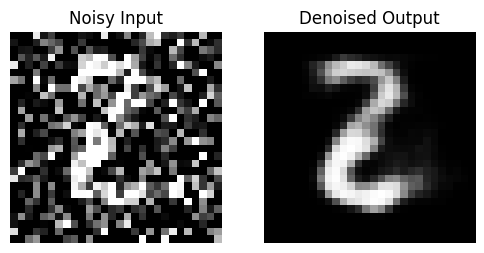

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape

# 1. Load dataset
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize images
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Reshape to (28, 28, 1)
x_train = np.reshape(x_train, (-1, 28, 28, 1))
x_test = np.reshape(x_test, (-1, 28, 28, 1))

# 2. Add noise
noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(size=x_test.shape)

# Clip values to [0,1]
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# 3. Build Autoencoder
input_img = Input(shape=(28, 28, 1))

# Encoder
x = Flatten()(input_img)
x = Dense(128, activation='relu')(x)
encoded = Dense(64, activation='relu')(x)

# Decoder
x = Dense(128, activation='relu')(encoded)
x = Dense(28 * 28, activation='sigmoid')(x)
decoded = Reshape((28, 28, 1))(x)

# Model
autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# 4. Train
autoencoder.fit(
    x_train_noisy, x_train,
    epochs=5,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

# 5. Predict (denoise)
decoded_imgs = autoencoder.predict(x_test_noisy)

# 6. Display one example
n = 1  # show one image
plt.figure(figsize=(6, 3))

# Noisy input
plt.subplot(1, 2, 1)
plt.title("Noisy Input")
plt.imshow(x_test_noisy[n].reshape(28, 28), cmap='gray')
plt.axis('off')

# Model prediction
plt.subplot(1, 2, 2)
plt.title("Denoised Output")
plt.imshow(decoded_imgs[n].reshape(28, 28), cmap='gray')
plt.axis('off')

plt.show()